In [25]:
!pip install langgraph langchain langchain-google-genai google-generativeai

In [26]:
from langgraph.graph import StateGraph, START, END #START and END are dummy nodes in LangGraph
from typing import TypedDict #Special type of Dict where we store the keys along with the datatype
from langchain_google_genai import ChatGoogleGenerativeAI #this helps in configuring our LLM
from langchain_core.tools import tool
from IPython.display import Image #we will use this for visualizing the Sequential Workflow

In [27]:
#Building the State
class TelecomState(TypedDict):
  customer_issue:str
  location:str
  network_status:str
  priority:str
  final_action:str


In [28]:
import os
os.environ["GOOGLE_API_KEY"]=""

llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash",temperature=0)

In [29]:
@tool #decorator
def network_diagnosis_tool(location:str)->str: #name of the tool is - network_diagnosis_tool
  #this tool takes location as input and format (dtype) for this input is string
  """This tool simulates telecom network diagnostics""" #description

  if location.lower() in ['mumbai','delhi','bangalore']:
    return "Network Congestion Detected"
  return "Network Stable"

In [30]:
#Creating our first node that checks the network congestion
def check_network(state:TelecomState)->TelecomState:
  result=network_diagnosis_tool.invoke(state['location'])
  #this node uses a Tool called 'network_diagnosis_tool' for checking the network congestion based on predefined conditions
  state['network_status']=result

  return state

In [31]:
#Creating our second node that is responsible for prioritizing the complaint
def analyze_priority(state:TelecomState)->TelecomState:
  prompt=f'''
  You are a telecom support expert.

  Customer_issue:{state['customer_issue']}
  Network_issue:{state['network_status']}

  Decide complaint priority and only return one word -
  - HIGH
  - MEDIUM
  - LOW
  '''
  response=llm.invoke(prompt)
  state['priority']=response.content.strip()
  return state

In [32]:
#Creating our last node - helpful for getting the final decision
def final_decision(state:TelecomState)->TelecomState:

  if state['priority']=='HIGH':
    state['final_action']='Escalate to Network Engineering Team'

  elif state['priority']=='MEDIUM':
    state['final_action']='Assign to Customer Support Team'

  else:
    state['final_action']='Send automated troubleshooting guide to the Customer'

  return state

In [33]:
graph=StateGraph(TelecomState) #creating our graph

In [35]:
#Within the Graph, we will add Nodes and will stitch the nodes together with Edges
graph.add_node("check_network",check_network)
graph.add_node("analyze_priority",analyze_priority)
graph.add_node("final_decision",final_decision)

graph.add_edge(START,"check_network") #E1
graph.add_edge("check_network","analyze_priority") #E2
graph.add_edge("analyze_priority","final_decision") #E3
graph.add_edge("final_decision",END) #E4

In [36]:
Workflow=graph.compile()

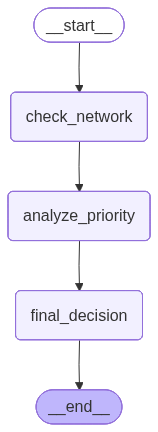

In [37]:
Workflow

In [38]:
initial_state:TelecomState={
    "customer_issue":"Internet outage for last 6-7 Hours",
    "location":"Mumbai"
}

result=Workflow.invoke(initial_state)
print(result)

{'customer_issue': 'Internet outage for last 6-7 Hours', 'location': 'Mumbai', 'network_status': 'Network Congestion Detected', 'priority': 'HIGH', 'final_action': 'Escalate to Network Engineering Team'}
